### Analogue script to Coefficients_ERA5_ICE
The last cell creates a final dataset for the two ERA5 coefficient sets for ice and land, that requires the output of both scripts. 

In [2]:
import pandas as pd
# import os
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import itertools
sns.set_theme(style="darkgrid")

# Show current working directory
# print("Current Working Directory: ", os.getcwd())


In [ ]:
### LOAD LAND DATASETS (PROMICE AND ERA5)

# # File paths
aws_path_land = '/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/data4simon/aws_temperature.csv'
era5_path_land = '/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/t2m_at_GEM_full.csv'

# Load data
aws_data_land = pd.read_csv(aws_path_land, index_col=0, parse_dates=True)
aws_data_land = aws_data_land.reset_index().rename(columns={'Date': 'date'})
era5_data_land = pd.read_csv(era5_path_land, index_col=0, parse_dates=True)

# Rename values in 'aws' column to match with AWS dataset
era5_data_land = era5_data_land.rename(columns={'Zackenberg_M4_30min': 'Zackenberg_M4'})

# Restructure ERA5 table to match with AWS table (preparation for merging)
era5_data_land = era5_data_land.reset_index().rename(columns={'id': 'date'})
era5_data_land_long = (
    era5_data_land
    .melt(id_vars=['date'], var_name='aws', value_name='t2m_era5')
    .dropna(subset=['t2m_era5'])  # Drop rows where t2m_era5 is NaN
    .sort_values(by=['aws', 'date'], ignore_index=True)
)

# Merge AWS and ERA5 data on 'date' and 'aws'
df_land = pd.merge(
    aws_data_land,
    era5_data_land_long,
    on=['aws', 'date'],
    how='inner'
)

print(df_land.head(),'\n')

        date  temperature              aws  t2m_era5
0 2007-08-28     9.140638  Kobbefjord_M500  9.379700
1 2007-08-29     7.272083  Kobbefjord_M500  6.501038
2 2007-08-30     4.298750  Kobbefjord_M500  5.600861
3 2007-08-31     3.808125  Kobbefjord_M500  4.359985
4 2007-09-01     2.517292  Kobbefjord_M500  4.939270 

['Disko_AWS2' 'Kobbefjord_M500' 'Zackenberg_M2' 'Zackenberg_M3'
 'Zackenberg_M4']
['Kobbefjord_M500' nan 'Disko_AWS2' 'Zackenberg_M2' 'Zackenberg_M3'
 'Zackenberg_M4']
['Kobbefjord_M500' 'Disko_AWS2' 'Zackenberg_M2' 'Zackenberg_M3'
 'Zackenberg_M4']


### Retrieve coefficients and make plots
Regression between ERA5 data and GEM AWS measurements. 


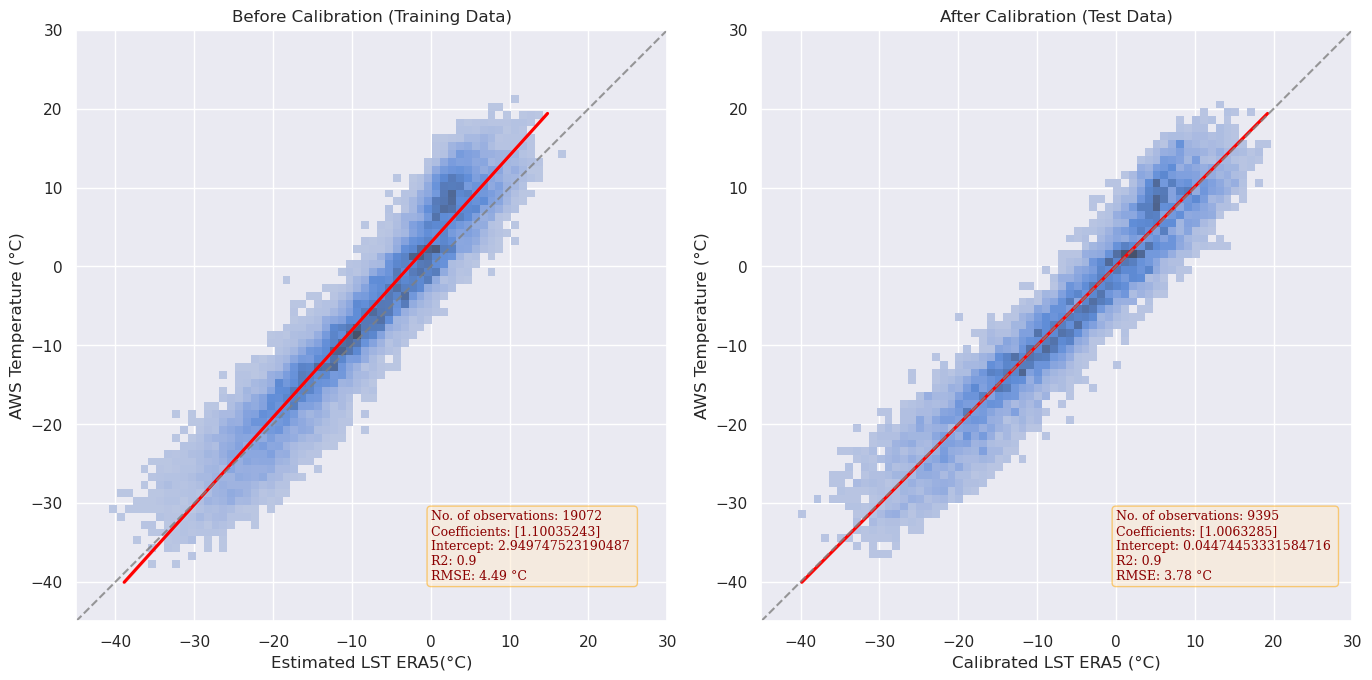

In [20]:
def split_mod_viz(df):

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['t2m_era5']], train_df['temperature'])
    model.predict(test_df[['t2m_era5']])
    r2_train = round(model.score(train_df[['t2m_era5']], train_df['temperature']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['t2m_era5'] * model.coef_[0] + model.intercept_

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['temperature'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['temperature']), 2)

    # Calculate RMSE of the calibration results
    rmse_before = ((test_df['t2m_era5'] - test_df['temperature']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['temperature']) ** 2).mean() ** 0.5

    s1 = f'No. of observations: {len(train_df)} \nCoefficients: {model.coef_} \nIntercept: {model.intercept_} \nR2: {r2_train} \nRMSE: {rmse_before:.2f} °C'
    s2 = f'No. of observations: {len(test_df)} \nCoefficients: {model2.coef_} \nIntercept: {model2.intercept_} \nR2: {r2_test} \nRMSE: {rmse_after:.2f} °C'

    ### GRAPHICAL VISUALIZATION ###
    # Create comparison plot of original vs calibrated values
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # Add 1:1 reference line 
    min_val = -45
    max_val = 30

    # 
    font = {'family': 'serif',
            'color':  'darkred',
            'weight': 'normal',
            'size': 9,
            }
    
    bbox = dict(
        boxstyle='round', 
        fc='blanchedalmond', 
        ec='orange', 
        alpha=0.5)

    # 2d HISTOGRAM PLOTS
    # Original est_temp plot
    sns.histplot(ax=ax1, data=train_df, x='t2m_era5', y='temperature', bins=60, discrete=True)
    sns.regplot(ax=ax1, data=test_df, x='t2m_era5', y='temperature', scatter=False, color='red')
    ax1.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax1.text(0.6, 0.07, s1, fontdict=font, bbox=bbox, transform=ax1.transAxes, horizontalalignment='left')
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    ax1.set_xlabel('Estimated LST ERA5(°C)')
    ax1.set_ylabel('AWS Temperature (°C)')
    ax1.set_title('Before Calibration (Training Data)')
    ax1.set_aspect('equal')

    # Calibrated est_temp plot
    sns.histplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', bins=60, discrete=True)
    sns.regplot(ax=ax2, data=test_df, x='lst_calibrated', y='temperature', scatter=False, color='red')
    ax2.plot([min_val, max_val], [min_val, max_val], '--', color='gray', alpha=0.8)
    ax2.text(0.6, 0.07, s2, fontdict=font, bbox=bbox, transform=ax2.transAxes, horizontalalignment='left')
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    ax2.set_xlabel('Calibrated LST ERA5 (°C)')
    ax2.set_ylabel('AWS Temperature (°C)')
    ax2.set_title('After Calibration (Test Data)')
    ax2.set_aspect('equal')
    plt.tight_layout()
    plt.show()

split_mod_viz(df_land)


In [ ]:
#%% different scale plots - Shunan
# Integrate this chunk into the plots to make colorbars aligned with the jointplot
sns.set_theme(style="darkgrid", font="Arial", font_scale=2)
g = sns.jointplot(x="visnirAlbedo", y="Albedo_theta<70d", data=df, kind="hist", 
                  height=8, xlim=(0,1), ylim=(0,1), cbar=True, vmin=0, vmax=55)
g.ax_joint.axline((0, 0), (1, 1), linewidth=1, color='k', linestyle='--')                       
g.plot_joint(sns.regplot, color='r', scatter=False)
g.set_axis_labels(xlabel="visnir albedo", ylabel="PROMICE albedo")

# ref https://stackoverflow.com/a/60849048/13318759
# get the current positions of the joint ax and the ax for the marginal x
pos_joint_ax = g.ax_joint.get_position()
pos_marg_x_ax = g.ax_marg_x.get_position()
# reposition the joint ax so it has the same width as the marginal x ax
g.ax_joint.set_position([pos_joint_ax.x0, pos_joint_ax.y0, pos_marg_x_ax.width, pos_joint_ax.height])
# reposition the colorbar using new x positions and y positions of the joint ax
g.fig.axes[-1].set_position([.96, pos_joint_ax.y0, .07, pos_joint_ax.height])


### Coefficients per station

In [ ]:
# COEFFICIENTS AND NSE FOR EACH STATION AND ALL SENSORS AS TABLE
stations = df_land['aws'].unique()

# Calculate NSE for every station in order to compare the goodness of fit across stations
def nse(df):
    """Nash-Sutcliffe Efficiency (NSE) as per `Nash and Sutcliffe, 1970
    <https://doi.org/10.1016/0022-1694(70)90255-6>`_.
    :Calculation Details:
        .. math::
           E_{\\text{NSE}} = 1 - \\frac{\\sum_{i=1}^{N}[e_{i}-s_{i}]^2}
           {\\sum_{i=1}^{N}[e_{i}-\\mu(e)]^2}
        where *N* is the length of the *simulations* and *evaluation*
        periods, *e* is the *evaluation* series, *s* is (one of) the
        *simulations* series, and *μ* is the arithmetic mean.
    https://github.com/ThibHlln/hydroeval/tree/v0.1.0
    Thibault Hallouin, 2021. hydroeval: an evaluator for streamflow time series in Python. https://doi.org/10.5281/zenodo.4709652        
    """
    obs = df['temperature'].to_numpy(dtype=np.float64)
    pred = df['lst_calibrated'].to_numpy(dtype=np.float64)
    
    nse_ = 1 - (
            np.sum((obs - pred) ** 2, axis=0, dtype=np.float64)
            / np.sum((obs - np.mean(obs)) ** 2, dtype=np.float64)
    )
    return nse_


def split_mod_df(df):

    # Split data into training and testing sets (2/3 training, 1/3 testing)
    train_df, test_df = train_test_split(df, test_size=0.33, random_state=42)

    # Regression model fit and prediction
    model = LinearRegression()
    model.fit(train_df[['t2m_era5']], train_df['temperature'])
    model.predict(test_df[['t2m_era5']])
    r2_train = round(model.score(train_df[['t2m_era5']], train_df['temperature']), 2)

    # Apply calibration to test dataset
    test_df['lst_calibrated'] = test_df['t2m_era5'] * model.coef_[0] + model.intercept_

    # Reveal coefficients of the calibrated model
    model2 = LinearRegression()
    model2.fit(test_df[['lst_calibrated']], test_df['temperature'])
    r2_test = round(model2.score(test_df[['lst_calibrated']], test_df['temperature']), 2)

    # Calculate RMSE and NSE of the calibration results
    rmse_before = ((test_df['t2m_era5'] - test_df['temperature']) ** 2).mean() ** 0.5
    rmse_after = ((test_df['lst_calibrated'] - test_df['temperature']) ** 2).mean() ** 0.5
    nse_after = round(nse(test_df),2)

    return {
        "n_obs": len(df),
        "coef_before": model.coef_[0],
        "intercept_before": model.intercept_,
        'R-squared_before': r2_train,
        'rmse_before': rmse_before,
        "coef_calibrated": model2.coef_[0],
        "intercept_calibrated": model2.intercept_,
        "R-squared_after": r2_test,
        'rmse_after': rmse_after,
        "NSE": nse_after
        }


##### FOR EACH Station

results_pr_staton = []

for station in stations:
    df_per_station = df_land[df_land['aws'] == station]
    results_pr_staton.append(split_mod_df(df_per_station))
    results_pr_staton[-1]['Station'] = station

df_results_station = pd.DataFrame(results_pr_staton)
df_results_station.sort_values(by='NSE', ascending=False, inplace=True)
print(df_results_station)
# df_results_station.to_csv('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/Coefficients_ERA5_GEM_Stations.csv', index=False)

   n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
1   4386     1.132709          2.113102              0.95     2.786751   
0   6131     0.947310          0.101095              0.94     2.361683   
3   6807     1.139349          6.162504              0.93     5.797710   
2   6592     1.236286          4.080353              0.93     4.777648   
4   4551     1.285977          4.469702              0.92     5.108583   

   coef_calibrated  intercept_calibrated  R-squared_after  rmse_after   NSE  \
1         0.995156             -0.149253             0.95    2.223105  0.95   
0         1.011099              0.053770             0.94    2.307258  0.94   
3         0.995997              0.077699             0.93    3.215033  0.93   
2         0.994908              0.115002             0.92    3.627911  0.92   
4         1.009355             -0.144823             0.92    3.710527  0.92   

           Station  
1       Disko_AWS2  
0  Kobbefjord_M500  
3    Zackenberg_M

### Calculate the overall calibration coefficients

In [ ]:
results_land = pd.DataFrame([split_mod_df(df_land)])
# results_land.to_csv('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/coefficients_era5_land.csv', index=False)

print(results_land,'\n')


   n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
0  28467     1.100352          2.949748               0.9     4.492449   

   coef_calibrated  intercept_calibrated  R-squared_after  rmse_after  NSE  
0         1.006329              0.044745              0.9    3.778098  0.9   



In [ ]:
results_land['area'] = 'land'

results_ice = pd.read_csv('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/coefficients_era5_ice.csv')
results_ice['area'] = 'ice'

combined_results = pd.concat([results_land, results_ice], ignore_index=True)
print(combined_results)

# combined_results.to_csv('/home/sirsimsius/Dokumente/Arbeit/KU/GEMLST/GEMLST_MODIS/Data/ERA5/coefficients_lookup_era5.csv', index=False)

   n_obs  coef_before  intercept_before  R-squared_before  rmse_before  \
0  28467     1.100352          2.949748              0.90     4.492449   
1  91474     1.026385          0.589599              0.91     3.280753   

   coef_calibrated  intercept_calibrated  R-squared_after  rmse_after  NSE  \
0         1.006329              0.044745              0.9    3.778098  0.9   
1         1.001885              0.062475              0.9    3.262508  0.9   

   area  
0  land  
1   ice  
